In [2]:
import numpy as np
import matplotlib.pyplot as plt

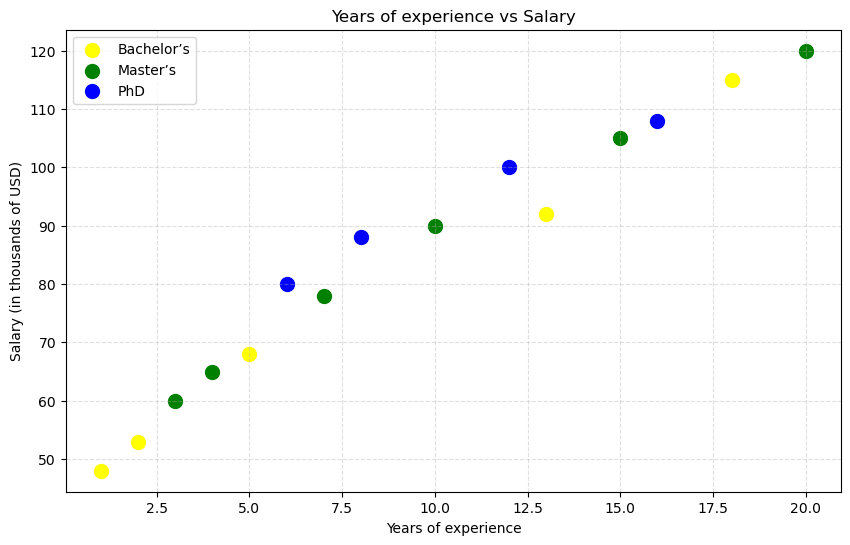

In [11]:
years_of_experience = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 15, 16, 18, 20]
education_level = [0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 1, 2, 0, 1]
location = [0, 1, 1, 2, 0, 2, 2, 1, 1, 0, 2, 2, 1, 0, 1]
salary = [48, 53, 60, 65, 68, 80, 78, 88, 90, 100, 92, 105, 108, 115, 120]

colors = ['yellow', 'green', 'blue']  
labels = ['Bachelor’s', 'Master’s', 'PhD']

plt.figure(figsize=(10, 6))

for level_of_education in range(3):
    x = [years_experience[i] for i in range(len(education_level)) if education_level[i] == level_of_education]
    y = [salary[i] for i in range(len(education_level)) if education_level[i] == level_of_education]
    
    plt.scatter(x, y, color=colors[level_of_education], label=labels[level_of_education], s=100)

plt.title('Years of experience vs Salary')
plt.xlabel('Years of experience')
plt.ylabel('Salary (in thousands of USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

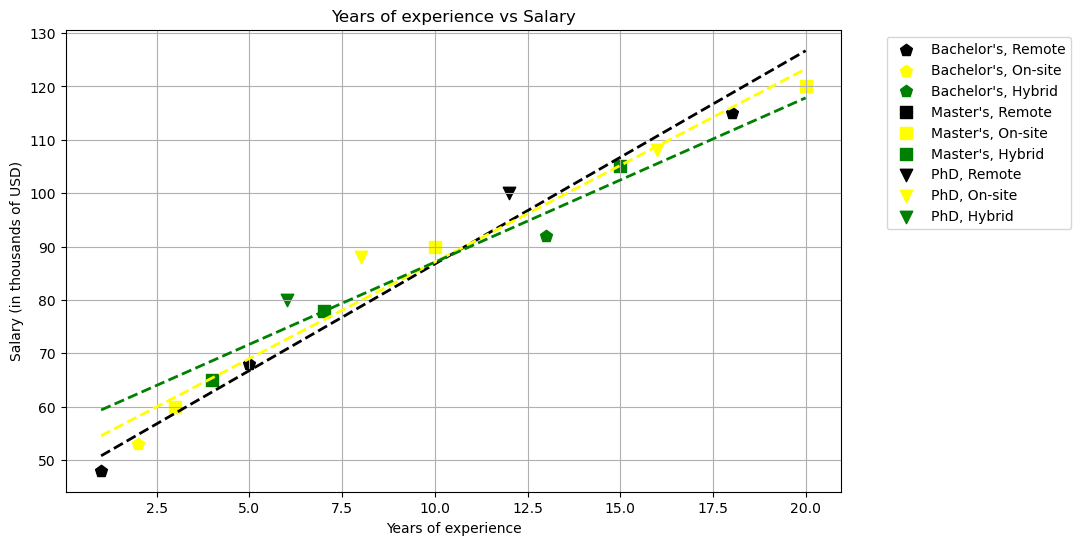

Model Coefficients (Intercept, Experience, Experience², Education, Location):
[44.79578505  4.82379985 -0.06205093  3.74181913 -1.03733902]

Predicted salary for 9 years, Master's, Remote: $86.93k
Predicted salary for 14 years, PhD, Hybrid: $105.58k


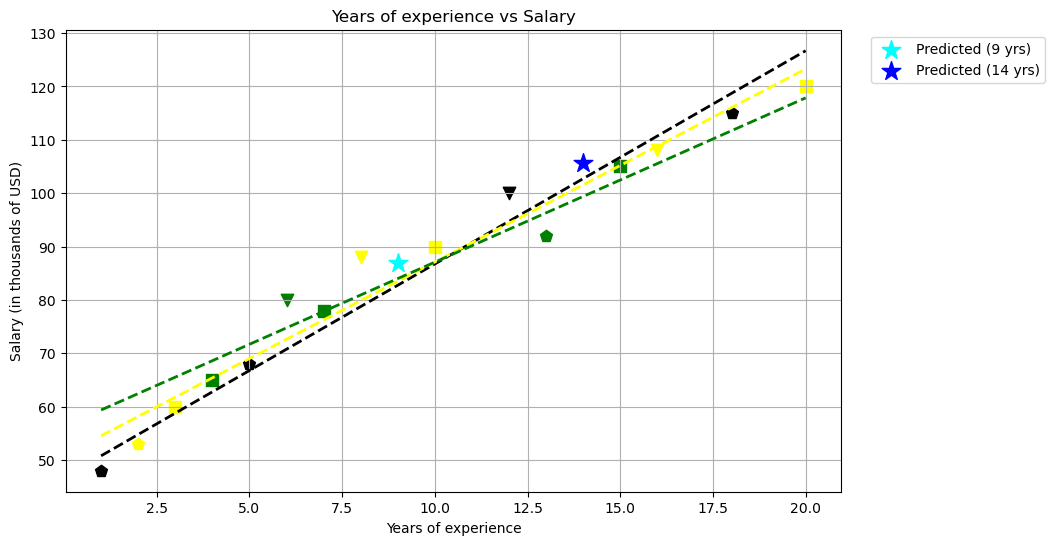

In [25]:
import numpy as np
import matplotlib.pyplot as plt

years_of_experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 15, 16, 18, 20])
education_level = np.array([0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 1, 2, 0, 1])
location = np.array([0, 1, 1, 2, 0, 2, 2, 1, 1, 0, 2, 2, 1, 0, 1])
salary = np.array([48, 53, 60, 65, 68, 80, 78, 88, 90, 100, 92, 105, 108, 115, 120])
        
locations = ['Remote', 'On-site', 'Hybrid']
education_levels = ["Bachelor's", "Master's", "PhD"]
markers = ['p', 's', 'v']  
colors = ['black', 'yellow', 'green']  

plt.figure(figsize=(10, 6))

for e in range(3):
    for l in range(3):
        mask = (education_level == e) & (location == l)
        plt.scatter(years_of_experience[mask], salary[mask],
                    color=colors[l],
                    marker=markers[e],
                    s=80,
                    label=f"{education_levels[e]}, {locations[l]}")

for l in range(3):
    mask = (location == l)
    x = years_of_experience[mask]
    y = salary[mask]
    slope = np.polyfit(x, y, 1)[0]
    intercept = np.polyfit(x, y, 1)[1]
    x_line = np.linspace(min(years_of_experience), max(years_of_experience), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, color=colors[l], linestyle='--', linewidth=2)

plt.title("Years of experience vs Salary")
plt.xlabel("Years of experience")
plt.ylabel("Salary (in thousands of USD)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

X1 = years_of_experience
X2 = years_of_experience**2
X3 = education_level
X4 = location
X = np.column_stack((np.ones(len(years)), X1, X2, X3, X4))
y = salary.reshape(-1, 1)
coefficients = np.linalg.inv(X.T @ X) @ X.T @ y

print("Model Coefficients (Intercept, Experience, Experience², Education, Location):")
print(coefficients.flatten())

x1 = np.array([1, 9, 9**2, 1, 0])   
x2 = np.array([1, 14, 14**2, 2, 2]) 
prediction1 = x1 @ coefficients
prediction2 = x2 @ coefficients

print()
print(f"Predicted salary for 9 years, Master's, Remote: ${prediction1[0]:.2f}k")
print(f"Predicted salary for 14 years, PhD, Hybrid: ${prediction2[0]:.2f}k")

plt.figure(figsize=(10, 6))
for e in range(3):
    for l in range(3):
        mask = (education_level == e) & (location == l)
        plt.scatter(years_of_experience[mask], salary[mask], color=colors[l], marker=markers[e], s=80)

for l in range(3):
    mask = (location == l)
    x = years_of_experience[mask]
    y = salary[mask]
    slope = np.polyfit(x, y, 1)[0]
    intercept = np.polyfit(x, y, 1)[1]
    x_line = np.linspace(min(years), max(years), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, color=colors[l], linestyle='--', linewidth=2)

plt.scatter(9, pred1, color='cyan', marker='*', s=200, label='Predicted (9 yrs)')
plt.scatter(14, pred2, color='blue', marker='*', s=200, label='Predicted (14 yrs)')

plt.title("Years of experience vs Salary")
plt.xlabel("Years of experience")
plt.ylabel("Salary (in thousands of USD)")
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left')
plt.grid(True)
plt.show()
